<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [21]:
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

iris = load_iris()
x = iris.data
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [17]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

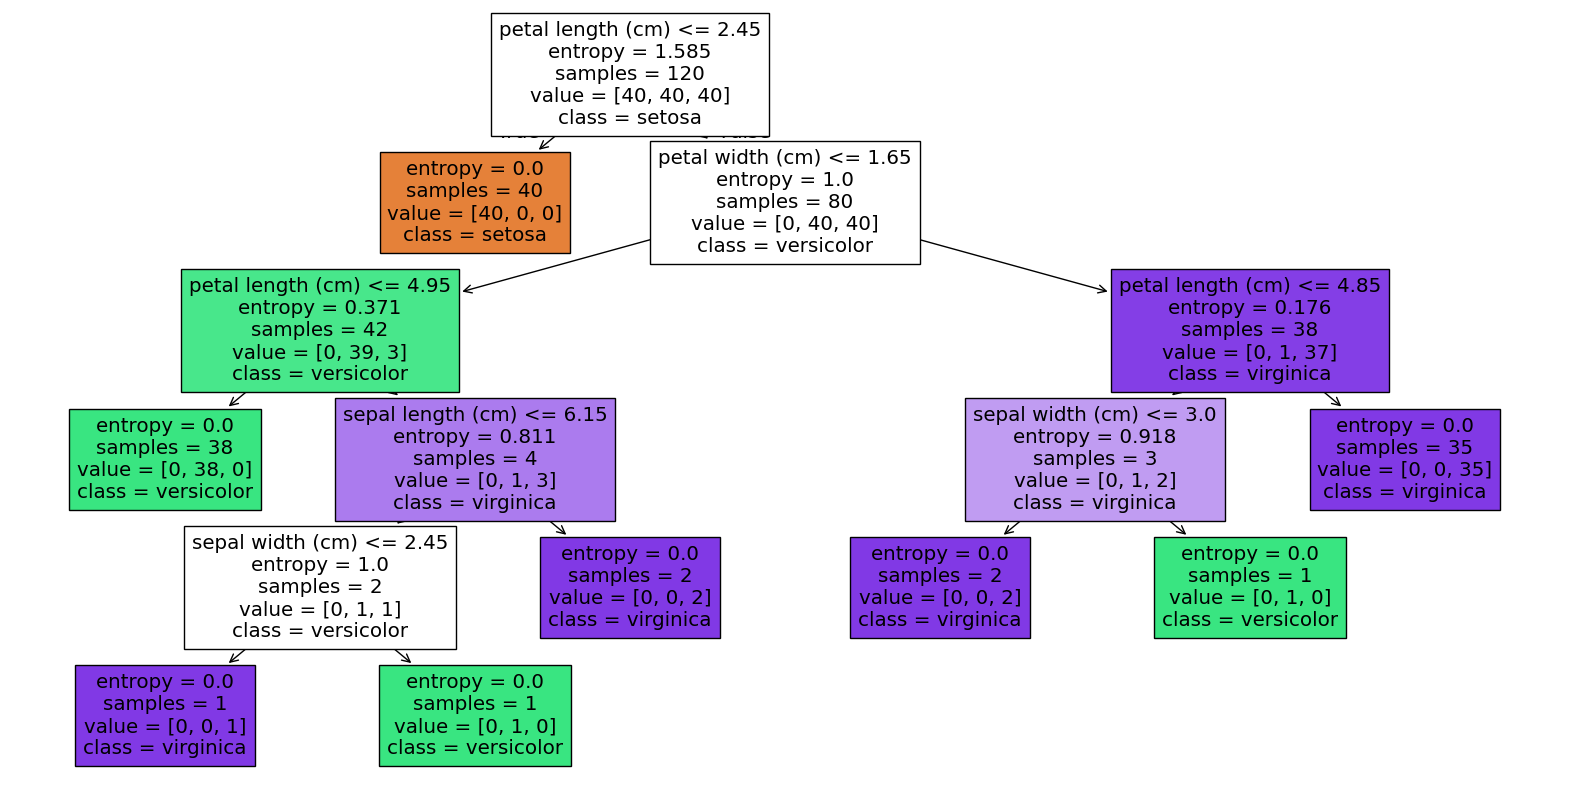

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()
##pedal length, entropy,samples , value ,classs esses aparecem na raiz, a profundidade é 6

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [25]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


lista_depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]


dados_tabela = []

for d in lista_depths:

    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    clf.fit(x_train, y_train)


    acc_treino = accuracy_score(y_train, clf.predict(x_train))
    acc_teste = accuracy_score(y_test, clf.predict(x_test))


    profundidade_real = clf.get_depth()
    num_folhas = clf.get_n_leaves()


    dados_tabela.append({
        "Configuração (max_depth)": "None" if d is None else d,
        "Profundidade Real": profundidade_real,
        "Nº de Folhas": num_folhas,
        "Acurácia Treino": f"{acc_treino:.4f}",
        "Acurácia Teste": f"{acc_teste:.4f}"
    })


df_resultado = pd.DataFrame(dados_tabela)
print(df_resultado.to_string(index=False))

Configuração (max_depth)  Profundidade Real  Nº de Folhas Acurácia Treino Acurácia Teste
                       1                  1             2          0.6667         0.6667
                       2                  2             3          0.9667         0.9333
                       3                  3             5          0.9833         0.9667
                       4                  4             7          0.9917         0.9333
                       5                  5             8          1.0000         0.9333
                       6                  5             8          1.0000         0.9333
                       7                  5             8          1.0000         0.9333
                       8                  5             8          1.0000         0.9333
                       9                  5             8          1.0000         0.9333
                    None                  5             8          1.0000         0.9333


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(x_train, y_train)


clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(x_train, y_train)


modelos = {
    "Gini": clf_gini,
    "Entropia": clf_entropy
}

print(f"{'Critério':<10} | {'Profundidade':<12} | {'Acurácia (Teste)':<15}")
print("-" * 45)

for nome, modelo in modelos.items():
    profundidade = modelo.get_depth()
    pred = modelo.predict(x_test)
    acuracia = accuracy_score(y_test, pred)
    print(f"{nome:<10} | {profundidade:<12} | {acuracia:.4f}")

Critério   | Profundidade | Acurácia (Teste)
---------------------------------------------
Gini       | 5            | 0.9333
Entropia   | 5            | 0.9333


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


profundidades = range(1, 11)
treino_acc = []
teste_acc = []

for d in profundidades:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    clf.fit(x_train, y_train)


    treino_acc.append(accuracy_score(y_train, clf.predict(x_train)))

    teste_acc.append(accuracy_score(y_test, clf.predict(x_test)))


melhor_idx = teste_acc.index(max(teste_acc))
melhor_profundidade = profundidades[melhor_idx]